In [ ]:
# repo-root bootstrap: notebooks live in notebooks/, code lives one level up
import sys, pathlib
_root = pathlib.Path.cwd()
if not (_root / "spphot_eval.py").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))


In [3]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

data = pl.scan_parquet('/scratch/mk27/mj8805/spphot_nn_results_gauss-beta0.5_merged.parquet')

In [4]:
import numpy as np

In [5]:
data.columns

/jobfs/172387365.gadi-pbs/ipykernel_2168899/2295596747.py:1: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  data.columns


['sdss_id',
 'sdss4_apogee_id',
 'gaia_dr2_source_id',
 'gaia_dr3_source_id_photogeo',
 'tic_v8_id',
 'healpix',
 'lead',
 'version_id',
 'catalogid',
 'catalogid21',
 'catalogid25',
 'catalogid31',
 'n_associated',
 'n_neighborhood',
 'crossmatch_flags',
 'sdss4_apogee_target1_flags',
 'sdss4_apogee_target2_flags',
 'sdss4_apogee2_target1_flags',
 'sdss4_apogee2_target2_flags',
 'sdss4_apogee2_target3_flags',
 'sdss4_apogee_member_flags',
 'sdss4_apogee_extra_target_flags',
 'ra',
 'dec',
 'l',
 'b',
 'plx',
 'e_plx',
 'pmra',
 'e_pmra',
 'pmde',
 'e_pmde',
 'gaia_v_rad',
 'gaia_e_v_rad',
 'g_mag',
 'bp_mag',
 'rp_mag',
 'j_mag',
 'e_j_mag',
 'h_mag',
 'e_h_mag',
 'k_mag',
 'e_k_mag',
 'ph_qual',
 'bl_flg',
 'cc_flg',
 'w1_mag',
 'e_w1_mag',
 'w1_flux',
 'w1_dflux',
 'w1_frac',
 'w2_mag',
 'e_w2_mag',
 'w2_flux',
 'w2_dflux',
 'w2_frac',
 'w1uflags',
 'w2uflags',
 'w1aflags',
 'w2aflags',
 'mag4_5',
 'd4_5m',
 'rms_f4_5',
 'sqf_4_5',
 'mf4_5',
 'csf',
 'zgr_teff',
 'zgr_e_teff',
 'zgr

In [8]:
filtered = data.filter(pl.col('plx_sp') < 1)

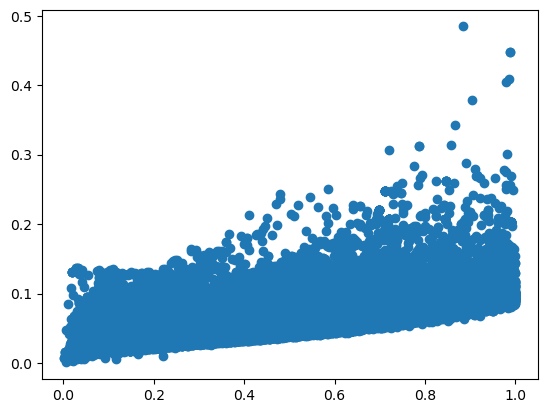

In [9]:
plt.scatter(filtered.select('plx_sp').collect(), filtered.select('err_sp').collect())

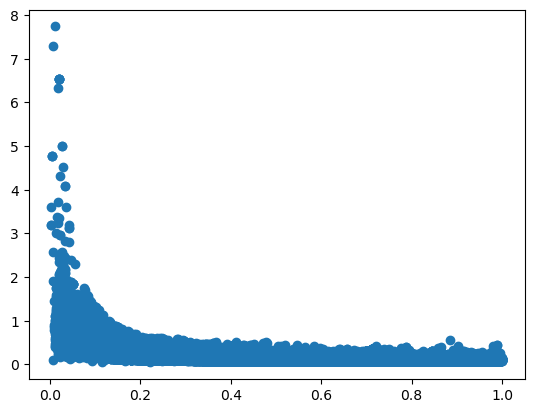

In [10]:
plt.scatter(filtered.select('plx_sp').collect(), filtered.select('err_sp').collect()/filtered.select('plx_sp').collect())

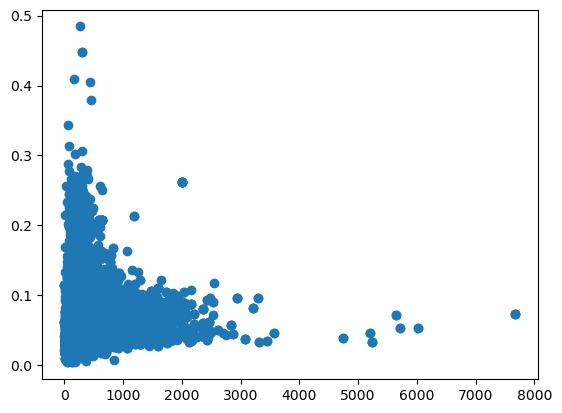

In [13]:
plt.scatter(filtered.select('snr_orig').collect(), filtered.select('err_sp').collect())

In [27]:
# Bin by SNR (e.g., 20 bins) and plot mean and std err_sp in each bin

import numpy as np

def plot_binned_err_sp(data, col='snr_orig', err_sp_col='err_sp', num_bins=20):
    # Collect the data into pandas Series for compatibility
    snr = data.select(col).collect().to_pandas()[col]
    err_sp = data.select(err_sp_col).collect().to_pandas()[err_sp_col]

        # Define bins
    bins = np.linspace(snr.min(), snr.max(), num_bins+1)
    bin_inds = np.digitize(snr, bins)

    bin_centers = []
    mean_err_sp = []
    std_err_sp = []

    for i in range(1, len(bins)):
        in_bin = (bin_inds == i)
        if in_bin.sum() > 0:
            bin_centers.append(snr[in_bin].mean())
            mean_err_sp.append(err_sp[in_bin].mean())
            std_err_sp.append(err_sp[in_bin].std())

    plt.errorbar(bin_centers, mean_err_sp, yerr=std_err_sp, fmt='o', color='black')
    plt.xlabel(col)
    plt.ylabel('err_sp')
    plt.title(f'err_sp binned by {col}')

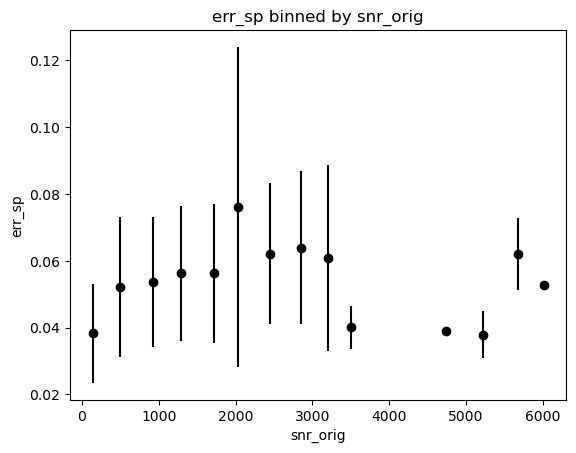

In [22]:
plot_binned_err_sp(filtered, 'snr_orig', 'err_sp')

In [34]:
teff_filtered = filtered.filter(pl.col('teff') < 8000)

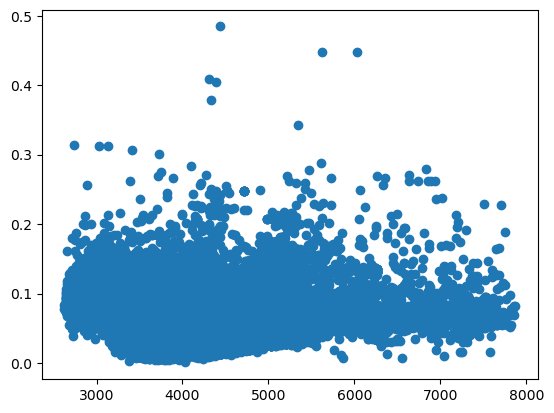

In [35]:
plt.scatter(teff_filtered.select('teff').collect(), teff_filtered.select('err_sp').collect())

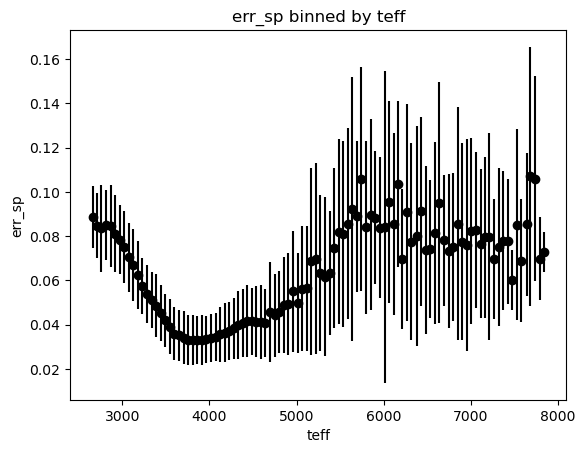

In [36]:
plot_binned_err_sp(teff_filtered, 'teff', 'err_sp', 100)

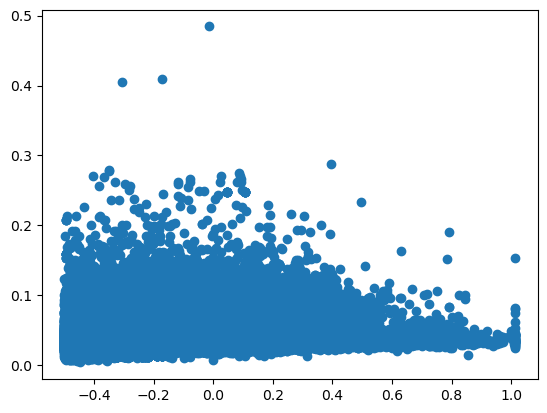

In [32]:
metallicity_filtered = filtered.filter(pl.col('fe_h') > -0.5)
plt.scatter(metallicity_filtered.select('fe_h').collect(), metallicity_filtered.select('err_sp').collect())


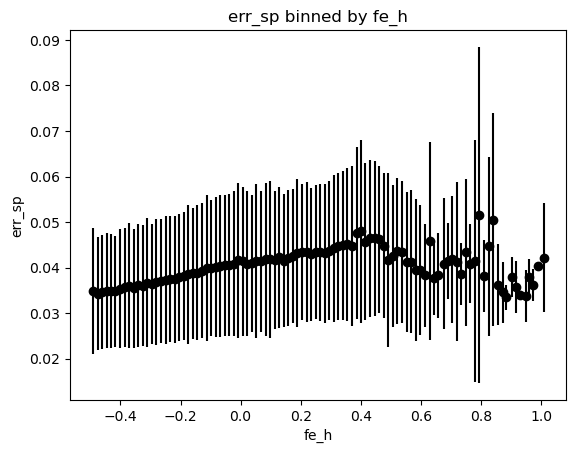

In [33]:
plot_binned_err_sp(metallicity_filtered, 'fe_h', 'err_sp', 100)

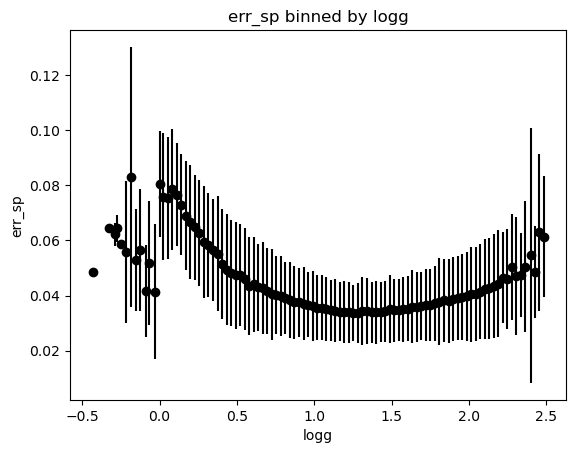

In [39]:
logg_filtered = filtered.filter(pl.col('logg') < 2.5)
plot_binned_err_sp(logg_filtered, 'logg', 'err_sp', 100)

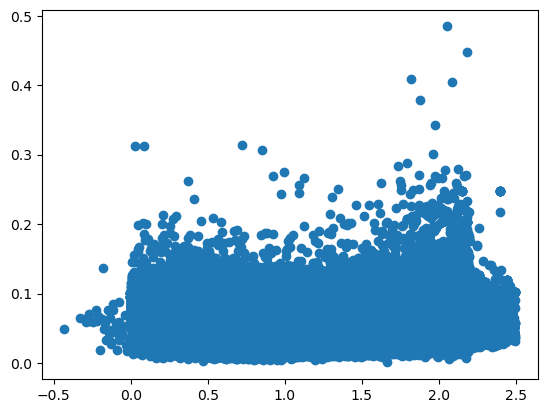

In [40]:
plt.scatter(logg_filtered.select('logg').collect(), logg_filtered.select('err_sp').collect())